# GMM (Gaussian Mixture Model)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Visualisation of our data

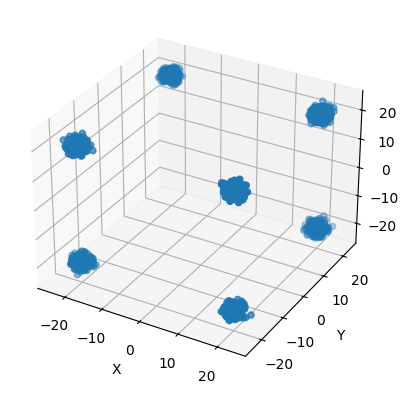

In [7]:
df = pd.read_csv('./data/dataGMM.txt', header=None, names=['x', 'y', 'z'], sep=' ')
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['x'], df['y'], df['z'])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

# Initialisation

In [14]:
X = df
print(X)

              x          y          z
0     18.439648  19.969022  19.379072
1     18.535420  21.411946  19.523268
2     19.219531  21.070268  18.717707
3     18.672521  20.126338  20.862194
4     20.696737  19.665435  19.002474
...         ...        ...        ...
3495 -21.567198 -20.713492 -19.317512
3496 -19.696379 -19.894350 -17.805988
3497 -19.380727 -18.369775 -17.965637
3498 -19.143419 -20.723108 -19.029425
3499 -19.464606 -20.754906 -20.428919

[3500 rows x 3 columns]


In [15]:
X.shape

(3500, 3)

# Dimension  
- $J = 7$
- $I = 3500$
- $N = 3$
- $\phi \in \mathbb{R}^{J}$
- $\mu \in \mathbb{R}^{N \times J}$
- $\Sigma \in \mathbb{R}^{N \times N \times J}$
But in our case we're going to use mostly of the time $\Sigma_{j} \in \mathbb{R}^{N \times N}$
- $\theta = \{\phi, \mu, \Sigma\}$

In [43]:
J = 7
I = X.shape[0]
phi = np.full(J, 1/J)
N = 3
mu = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0),(J,N))
Sigma = np.array([np.eye(N) for _ in range(J)])
theta = {'phi': phi, 'mu': mu, 'Sigma': Sigma}

# EM Algorithm

We take the convergence criterion log likelihood with an $\epsilon$, so it'll verify
$$l(\theta^{(t+1)}) - l(\theta^{(t)}) < \epsilon$$

In [38]:
max_iter = 100
epsilon = 1e-4
log_likelihood_old = -np.inf
posterior = np.zeros((I,J))

## E-Step
To converge and find cluster we need to first do the expectation step which is the compute of $w_{j}^{(i)}$. The is called the **posterior** and is defined by 
$$w_{j}^{(i)} = Q_i(Z^{(i)} = j) = P(Z^{(i)} = j \mid X^{(i)};\theta) = \frac{P(X^{(i)} \mid Z^{(i)} = j;\theta)P(Z^{(i)} = j \mid \theta)}{P(X^{(i)} \mid \theta)}$$
With $P(X^{(i)} \mid Z^{(i)} = j;\theta)$ the conditional likelihood defined by
$$P(X^{(i)} \mid Z^{(i)} = j;\theta) = \frac{1}{(2 \pi)^{\frac{N}{2}}\left| \Sigma_{j} \right|^{\frac{1}{2}}}\text{exp}(-\frac{1}{2}(X^{(i)} - \mu_{j})^T \Sigma_{j}^{-1}(X^{(i)} - \mu_{j}))$$
And with $P(Z^{(i)} = j \mid \theta) = \phi_{j}$ called the **prior** and finally the **marginal likelihood** defined by
$$P(X^{(i)}\mid \theta) = \sum_{Z{(i)}} P(X^{(i)} , Z^{(i)}\mid \theta) = \sum_{k=1}^{J} P(X^{(i)}\mid Z^{(i)} = k;\theta) P(Z^{(i)} = k\mid \theta)$$
With $k \in \{1,\dots, J\}$, not the same with the parameter $j$

## M-Step
The intuition behind M-step is that we want to maximise the lower bound of marginal log likelihood as follow
$$\tilde{\theta}^{*} = \underset{\theta}{\operatorname{argmax}} \; \ell \ell(\theta)$$
And we update the parameter $\theta$ as follow
$$\forall j, \quad \phi_{j} = \frac{\sum_{i=1}^{I}w_{j}^{(i)}}{I}$$
$$\forall j, \quad \mu_{j} = \frac{\sum_{i=1}^{I}w_{j}^{(i)} X^{(i)}}{\sum_{i=1}^{I}w_{j}^{(i)}}$$
$$\forall j, \quad \Sigma_{j} = \frac{\sum_{i=1}^{I}w_{j}^{(i)} (X^{(i)} - \mu_{j})(X^{(i)} - \mu_{j})^T}{\sum_{i=1}^{I}w_{j}^{(i)}}$$

In [ ]:
if hasattr(X, 'to_numpy'):
    X = X.to_numpy()

for iteration in range(max_iter):

    log_likelihood_new = 0.0

    # E-STEP

    for i in range(I):
        marginal_likelihood = 0.0
        for k in range(J):
                pxt = (1 / (((2 * np.pi)**(N/2)) * np.sqrt(np.linalg.det(Sigma[k])))) * np.exp(-0.5 * (X[i] - mu[k]).T @ np.linalg.inv(Sigma[k]) @ (X[i] - mu[k]))
                marginal_likelihood += pxt * phi[k]

        log_likelihood_new += np.log(marginal_likelihood + 1e-10)

        for j in range(J):
            cond_likelihood = (1 / (((2 * np.pi)**(N/2)) * np.sqrt(np.linalg.det(Sigma[j])))) * np.exp(-0.5 * (X[i] - mu[j]).T @ np.linalg.inv(Sigma[j]) @ (X[i] - mu[j]))
            prior = phi[j]
            posterior[i][j] = (cond_likelihood * prior) / marginal_likelihood

    diff = np.abs(log_likelihood_new - log_likelihood_old)
    print(f"Itération {iteration} - Différence log-vraisemblance: {diff}")
    if diff < epsilon:
        break
    log_likelihood_old = log_likelihood_new

    # M-STEP

    for j in range(J):
        sum_w = 0.0
        for i in range(I):
            sum_w += posterior[i][j]
            
        phi[j] = sum_w / I
        
        new_mu = np.zeros(N)
        for i in range(I):
            new_mu += posterior[i][j] * X[i]
        mu[j] = new_mu / sum_w
        
        new_Sigma = np.zeros((N, N))
        for i in range(I):
            diff_vec = (X[i] - mu[j]).reshape(N, 1)
            new_Sigma += posterior[i][j] * (diff_vec @ diff_vec.T)
        Sigma[j] = new_Sigma / sum_w + (1e-6 * np.eye(N))

Itération 0 - Différence log-vraisemblance: inf
Itération 1 - Différence log-vraisemblance: 53184.588488911184
Itération 2 - Différence log-vraisemblance: 52.96923562584561
Itération 3 - Différence log-vraisemblance: 31.7450083247968
Itération 4 - Différence log-vraisemblance: 131.1219015362367
Itération 5 - Différence log-vraisemblance: 668.6782236124054
Itération 6 - Différence log-vraisemblance: 294.7555633758129
Itération 7 - Différence log-vraisemblance: 1.798580342438072e-07


# Inference and testing on new datas

In [ ]:
X_test = np.array([
    [20.0, 20.0, 20.0],  
    [-20.0, 20.0, 20.0],  
    [20.0, 20.0, -20.0],  
    [20.0, -20.0, 20.0], 
    [20.0, -20.0, -20.0] 
])

test_clusters = []

for x_t in X_test:
    probs = np.zeros(J)
    
    for j in range(J):
        diff = x_t - mu[j] 
        
        det = np.linalg.det(Sigma[j])
        inv = np.linalg.inv(Sigma[j])
        
        pdf = (1 / (((2 * np.pi)**(N/2)) * np.sqrt(abs(det) + 1e-10))) * np.exp(-0.5 * diff.T @ inv @ diff)
        
        probs[j] = phi[j] * pdf
        
    pred_cluster = np.argmax(probs)
    test_clusters.append(pred_cluster)

test_clusters = np.array(test_clusters)
print(f"IDs des clusters prédits pour les points de test : {test_clusters}")


IDs des clusters prédits pour les points de test : [6 3 0 6 5]


# Plot the results

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_9148/2894541110.py:23: SyntaxWarning: invalid escape sequence '\m'
  color='red', marker='X', s=200, label='Centres des clusters (\mu)')


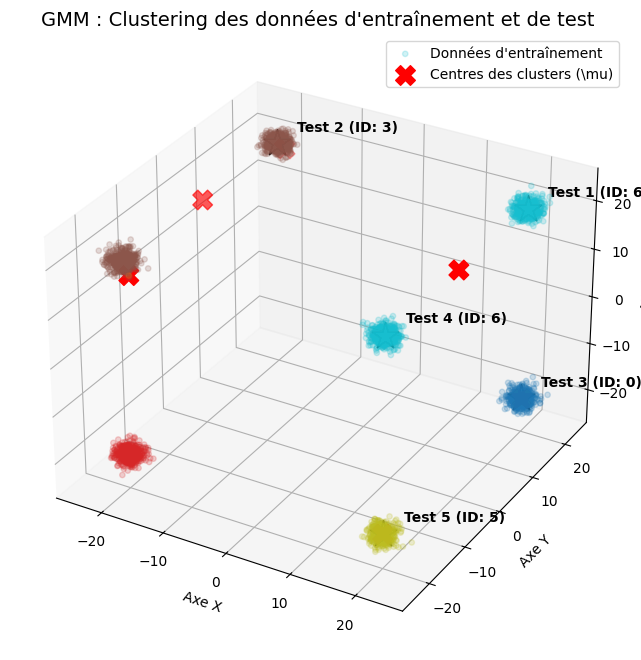

In [ ]:
# On récupère l'ID du cluster majoritaire pour chaque point d'entraînement
# 'posterior' est la matrice de la dernière itération de ta cellule précédente
train_clusters = np.argmax(posterior, axis=1)

# Création de la figure 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# On choisit une palette de couleurs avec suffisamment de couleurs différentes
cmap = plt.get_cmap('tab10')

# 1. Affichage des données d'entraînement (petits points transparents)
scatter_train = ax.scatter(X[:, 0], X[:, 1], X[:, 2], 
                           c=train_clusters, cmap=cmap, 
                           alpha=0.2, s=15, label="Données d'entraînement")

# 2. Affichage des centres des clusters (grandes croix rouges)
ax.scatter(mu[:, 0], mu[:, 1], mu[:, 2], 
           color='red', marker='X', s=200, label='Centres des clusters (\mu)')

# 3. Affichage des données de test (grandes étoiles)
for i, x_t in enumerate(X_test):
    # On donne à l'étoile la couleur de son cluster prédit
    color_idx = test_clusters[i] / (J - 1) if J > 1 else 0
    ax.scatter(x_t[0], x_t[1], x_t[2], 
               color=cmap(color_idx), marker='*', s=400, edgecolor='black')
    
    # On ajoute un petit texte à côté de l'étoile pour l'identifier
    ax.text(x_t[0] + 2, x_t[1] + 2, x_t[2] + 2, 
            f'Test {i+1} (ID: {test_clusters[i]})', 
            fontsize=10, weight='bold', color='black')

# Personnalisation du graphique
ax.set_title("GMM : Clustering des données d'entraînement et de test", fontsize=14)
ax.set_xlabel("Axe X")
ax.set_ylabel("Axe Y")
ax.set_zlabel("Axe Z")
ax.legend()

# Affichage !
plt.show()